In [1]:
##### Import #######

import random
import numpy as np
import asymmetree.treeevolve as te
import networkx as nx
import matplotlib.pyplot as plt
import copy

from asymmetree.visualization.tree_vis import visualize, assign_colors
from bmg_fun import convert_to_nx
from MISC_Functions import visualize_BCN, visualize_bmg, visualize_network, generateGeneTree_maxLeaves
from bmg_Tony import bmg
from all_BCEA import BCEA1 ,BCEA2, BCEA3, BCEA4
from BICcherry_reverse import BICcherry_reverse
from insert_hybrid import insertHybrid
from matplotlib import cm

In [ ]:
RUNS = 10000
MODE = 'weak'
maxLeaves = 30
hybridRange = (0,8)
speciesRange = (2,10)
if MODE == 'weak':
    count = np.zeros((RUNS,5))
elif MODE == 'strong':
    count = np.zeros((RUNS,3))

countWeakEdges = 0
countWNotS = 0
countSNotW = 0

for run in range(RUNS):
    nHybrids = random.randint(hybridRange[0],hybridRange[1])
    nSpecies = random.randint(speciesRange[0],speciesRange[1])

    _, geneTree = generateGeneTree_maxLeaves(nSpecies= nSpecies, max_leaves= maxLeaves)

    Tree = convert_to_nx(geneTree)

    Tree = insertHybrid(Tree,nHybrids)

    # Network = Tree.copy()

    WBMG = bmg(Tree, mode = 'weak')
    SBMG = bmg(Tree, mode = 'strong')

    for (node1,node2) in WBMG.edges:
        countWeakEdges += 1
        if not SBMG.has_edge(node1,node2):
            countWNotS += 1


    for edge in SBMG.edges:
        if not WBMG.has_edge(node1,node2):
            countSNotW += 1

    BMG = bmg(Tree, mode=MODE)
    BC1 = BCEA1(BMG)
    count[run][0] = int(nx.utils.graphs_equal(BMG, bmg(BC1,MODE)))

    BC2 = BCEA2(BMG)
    count[run][1] = int(nx.utils.graphs_equal(BMG, bmg(BC2,MODE)))
    BC3 = BCEA3(BMG, MODE)
    count[run][2] = int(nx.utils.graphs_equal(BMG, bmg(BC3,MODE)))
    if MODE == 'weak':
        BC4 = BCEA4(BMG)
        count[run][3] = int(nx.utils.graphs_equal(BMG, bmg(BC4,MODE)))
        BC5 = BICcherry_reverse(BMG, simplify=True)
        count[run][4] = int(nx.utils.graphs_equal(BMG, bmg(BC5,MODE)))

print(countWeakEdges,countSNotW,countWNotS)

13012 0 149


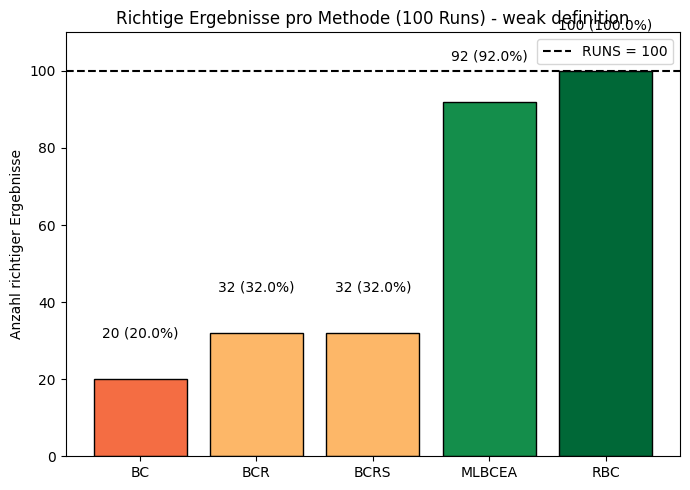

In [3]:
##################################
############## Plot ##############
##################################


if MODE == 'weak':
    labels = ['BC', 'BCR', 'BCRS', 'MLBCEA', 'RBC']

if MODE =='strong':
    labels = ['BC', 'BCR', 'BCEA']

werte = np.sum(count, axis=0)

# Farbgradient: 0% = rot, 100% = grün
cmap = plt.get_cmap('RdYlGn')   # rot -> gelb -> grün
farben = cmap(werte / RUNS)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, werte, color=farben, edgecolor='black')

# Horizontale Linie bei y = RUNS
ax.axhline(RUNS, color='black', linestyle='--', linewidth=1.5, label=f'RUNS = {RUNS}')

# Werte über den Balken anzeigen
for bar, w in zip(bars, werte):
    ax.text(bar.get_x() + bar.get_width() / 2, w + 10,
            f'{int(w)} ({w / RUNS:.1%})', ha='center', va='bottom')

ax.set_title(f'Richtige Ergebnisse pro Methode ({RUNS} Runs) - {MODE} definition')
ax.set_ylabel('Anzahl richtiger Ergebnisse')
ax.set_ylim(0, RUNS * 1.1)
ax.legend()

sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 100))

plt.tight_layout()
plt.show()


[[1. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 1.]
 [0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [1. 1. 1.

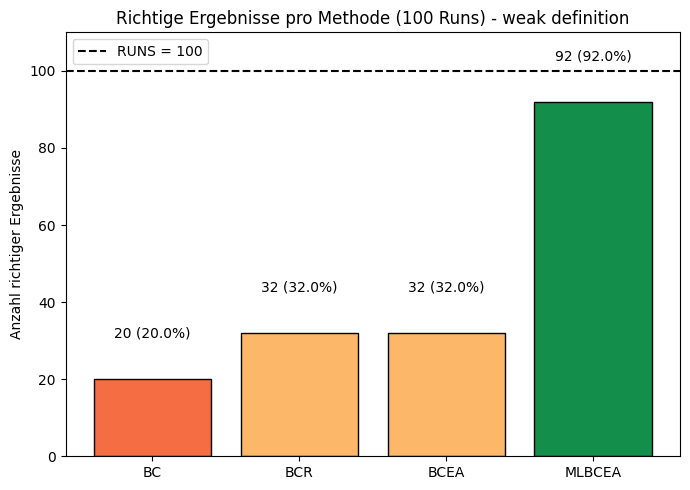

In [4]:
##################################
############## Plot without Reverse BC ##############
##################################

count2 = copy.copy(count)
count2 = count2[:,:4]

print(count)
print(count2)

if MODE == 'weak':
    labels = ['BC', 'BCR', 'BCEA', 'MLBCEA']

if MODE =='strong':
    labels = ['BC', 'BCR', 'BCEA']

werte = np.sum(count2, axis=0)

# Farbgradient: 0% = rot, 100% = grün
cmap = plt.get_cmap('RdYlGn')   # rot -> gelb -> grün
farben = cmap(werte / RUNS)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, werte, color=farben, edgecolor='black')

# Horizontale Linie bei y = RUNS
ax.axhline(RUNS, color='black', linestyle='--', linewidth=1.5, label=f'RUNS = {RUNS}')

# Werte über den Balken anzeigen
for bar, w in zip(bars, werte):
    ax.text(bar.get_x() + bar.get_width() / 2, w + 10,
            f'{int(w)} ({w / RUNS:.1%})', ha='center', va='bottom')

ax.set_title(f'Richtige Ergebnisse pro Methode ({RUNS} Runs) - {MODE} definition')
ax.set_ylabel('Anzahl richtiger Ergebnisse')
ax.set_ylim(0, RUNS * 1.1)
ax.legend()

sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 100))

plt.tight_layout()
plt.show()
